# I/O and Tree basics

Load sample FlyWire SWC morphologies, inspect a `Tree`, and plot a 2D projection.

See also the markdown tutorials on [I/O](../tutorials/02_io.md) and [Tree basics](../tutorials/03_tree_basics.md).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import NeuRosetta as nr

%matplotlib inline

SAMPLE_SWC = "720575940596125868.swc"


def find_data_dir() -> Path:
    """Resolve docs/data from repo root, docs/, or notebook dir."""
    here = Path.cwd()
    for base in (here, here.parent, here.parent.parent):
        for rel in ("docs/data", "data"):
            candidate = (base / rel).resolve()
            if (candidate / SAMPLE_SWC).exists():
                return candidate
    raise FileNotFoundError(f"Could not find docs/data/{SAMPLE_SWC}")


DATA = find_data_dir()
print(f"Using sample data: {DATA}")
print(f"NeuRosetta {nr.__version__}")

Using sample data: /home/ndrummond@neuro.mpg.de/Code/NeuRosetta/docs/data
NeuRosetta 0.1.0


In [2]:
# Single SWC -> Tree; directory -> Forest
tree = nr.import_swc(DATA / SAMPLE_SWC)
forest = nr.import_swc(DATA)

print(tree)
print(f"Forest ids: {forest.ids()}")

Tree(ID=720575940596125868) with 2010 nodes
Forest ids: [720575940596125868, 720575940599459782, 720575940599704006, 720575940599729862]


In [3]:
print("ID:", tree.ID)
print("metadata:", tree.metadata)
print("graph vertices:", tree.graph.num_vertices(), "edges:", tree.graph.num_edges())

ID: 720575940596125868
metadata: {'units': 'nanometer', 'file_path': '/home/ndrummond@neuro.mpg.de/Code/NeuRosetta/docs/data/720575940596125868.swc', 'isReduced': False}
graph vertices: 2010 edges: 2009


In [4]:
print(f"nodes:      {tree.count_nodes()}")
print(f"branches:   {tree.count_branches()}")
print(f"leaves:     {tree.count_leaves()}")
print(f"roots:      {tree.count_roots()}")
print(f"cable len:  {tree.get_total_cable_length():.1f}")

nodes:      2010
branches:   100
leaves:     112
roots:      1
cable len:  404238.0


In [5]:
print("graph-level properties:", tree.list_properties("g"))
print("has coordinates:", tree.has_property("coordinates", level="all"))

graph-level properties: ['ID', 'metadata']
has coordinates: False


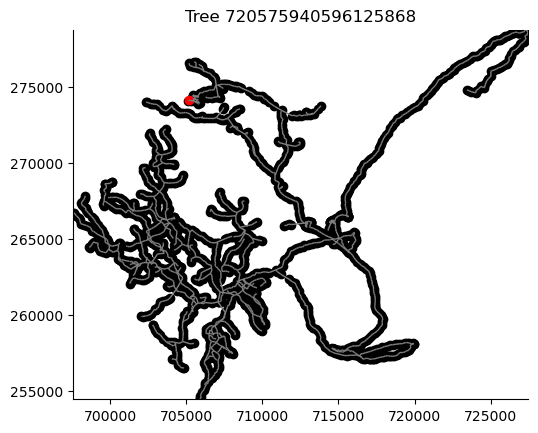

In [6]:
# 2D projection (matplotlib — safe for docs / headless builds)
ax = tree.show_2d()
ax.set_title(f"Tree {tree.ID}")
plt.show()

In [7]:
# Native .nr round-trip preserves metadata and graph properties
import tempfile

out = Path(tempfile.mkdtemp())
tree.set_units("nm")
tree.save_tree(out / f"{tree.ID}.nr")
reloaded = nr.load(out / f"{tree.ID}.nr")
print(reloaded.metadata.get("units"), reloaded.count_nodes())

nanometer 2010
